# L13 worked example: a fed-batch bioreactor as a neural ODE and a neural DAE

Four states: biomass $X$, product $P$, substrate $S$ and volume $V$. The balances are known; the
growth rate $\mu$ is learned by a network of the four states.

$$
\begin{align}
\frac{dX}{dt} &= \mu X - \frac{F}{V}X &
\frac{dP}{dt} &= Y_{px}\,\mu X - \frac{F}{V}P \\
\frac{dS}{dt} &= \frac{F}{V}(S_f - S) - \frac{\mu X}{Y_{xs}} &
\frac{dV}{dt} &= F
\end{align}
$$

`pip install sindae diffrax` installs everything.

## Run this first on Colab

Colab starts from its own preinstalled environment rather than this course's `uv`
environment, so run the cell below before anything else. It installs what this
notebook needs and Colab does not already have. Outside Colab it does nothing, so
you can run it or skip it.


In [ ]:
# Run this first on Colab. Anywhere else this cell does nothing.
#
# Only genuinely missing packages are installed, so Colab's own versions of
# everything it already ships are left alone.
import importlib.util
import subprocess
import sys

REQUIREMENTS = {
    "diffrax": "diffrax",
    "equinox": "equinox",
    "jax": "jax",
    "matplotlib": "matplotlib",
    "numpy": "numpy",
    "optax": "optax",
    "pandas": "pandas",
    "pyomo": "pyomo",
    "scipy": "scipy",
    "sindae": "sindae",
}


def _missing(module):
    try:
        return importlib.util.find_spec(module) is None
    except ModuleNotFoundError:  # the parent package is absent
        return True


if "google.colab" in sys.modules:
    need = sorted({pip for mod, pip in REQUIREMENTS.items() if _missing(mod)})
    if need:
        print("installing:", " ".join(need))
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", *need], check=True)
    print("Colab setup done." if need else "Colab: nothing to install.")


In [2]:
%matplotlib inline

import logging

import diffrax
import equinox as eqx
import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
import optax
import pandas as pd
import pyomo.dae as dae
import pyomo.environ as pyo
from scipy.integrate import solve_ivp

from sindae import HybridDAE
from sindae.algorithms.pretrain import PretrainConfig
from sindae.algorithms.simultaneous.train import SimultaneousConfig
from sindae.algorithms.smoother import SmootherConfig
from sindae.nn_utils import SimpleMLP
from sindae.plot_utils import plot_instance_data
from sindae.problem import ProblemDefinition
from sindae.solvers import SolverConfig

jax.config.update("jax_enable_x64", True)
logging.basicConfig(
    level=logging.INFO,
    format="%(message)s",
)
logging.getLogger("pyomo").setLevel(logging.ERROR)
logging.getLogger("cyipopt").setLevel(logging.WARNING)

## 1. The data

Three batches, 31 samples each over 40 h. The true kinetics, the Monod law
$\mu = \mu_{max} S / (K_s + S)$, only make the measurements and check the result.

In [3]:
FB_PARAMS = {
    "Feed": 0.05,     # F: volumetric feed rate (L/h)
    "Ypx": 0.2,       # product yield
    "Yxs": 0.5,       # biomass yield on substrate
    "Ks": 1.0,        # Monod constant (makes the data only)
    "mu_max": 0.2,    # Monod constant (makes the data only)
}
F, Ypx, Yxs = FB_PARAMS["Feed"], FB_PARAMS["Ypx"], FB_PARAMS["Yxs"]
STATE_NAMES = ["$X$ (biomass)", "$P$ (product)", "$S$ (substrate)", "$V$ (volume)"]
OUTPUT_NAME = [r"$\mu$ (growth rate)"]
SEED = 0

Each measurement gets random noise. A concentration cannot be negative, so a reading below zero
is recorded as zero.

In [4]:
BATCH_ICS = np.array([
    [0.05, 0.0, 10.0, 1.00],    # batch 0: X, P, S, V at t = 0
    [0.025, 0.0, 5.0, 0.80],    # batch 1
    [0.5, 0.0, 7.5, 0.95],      # batch 2
])
NOISE = np.array([0.05, 0.05, 0.5, 0.1])    # standard deviation of each measurement
t_obs = np.linspace(0, 40, 31)              # 31 samples over 40 h


def true_rhs(t, x, Sf):
    X, P, S, V = x
    mu = FB_PARAMS["mu_max"] * S / (FB_PARAMS["Ks"] + S)
    return [mu * X - F / V * X,
            Ypx * mu * X - F / V * P,
            F / V * (Sf - S) - mu * X / Yxs,
            F]


rng = np.random.default_rng(SEED)
obs_times = []
obs_values = []
for ic in BATCH_ICS:
    sol = solve_ivp(
        true_rhs,
        (0, 40),
        ic,
        t_eval=t_obs,
        args=(ic[2],),
        rtol=1e-10,
        atol=1e-12,
    )
    noisy = sol.y.T + rng.normal(0, 1, sol.y.T.shape) * NOISE
    obs_times.append(t_obs)
    obs_values.append(np.clip(noisy, 0, None))

pd.DataFrame(
    obs_values[0],
    index=pd.Index(t_obs.round(2), name="time (h)"),
    columns=["X", "P", "S", "V"],
).round(3).head()

,X,P,S,V
time (h),,,,
0.00,0.056,0.000,10.320,1.010
1.33,0.033,0.021,10.626,1.161
2.67,0.036,0.000,9.633,1.137
4.00,0.000,0.000,9.288,1.127
5.33,0.077,0.000,10.077,1.371


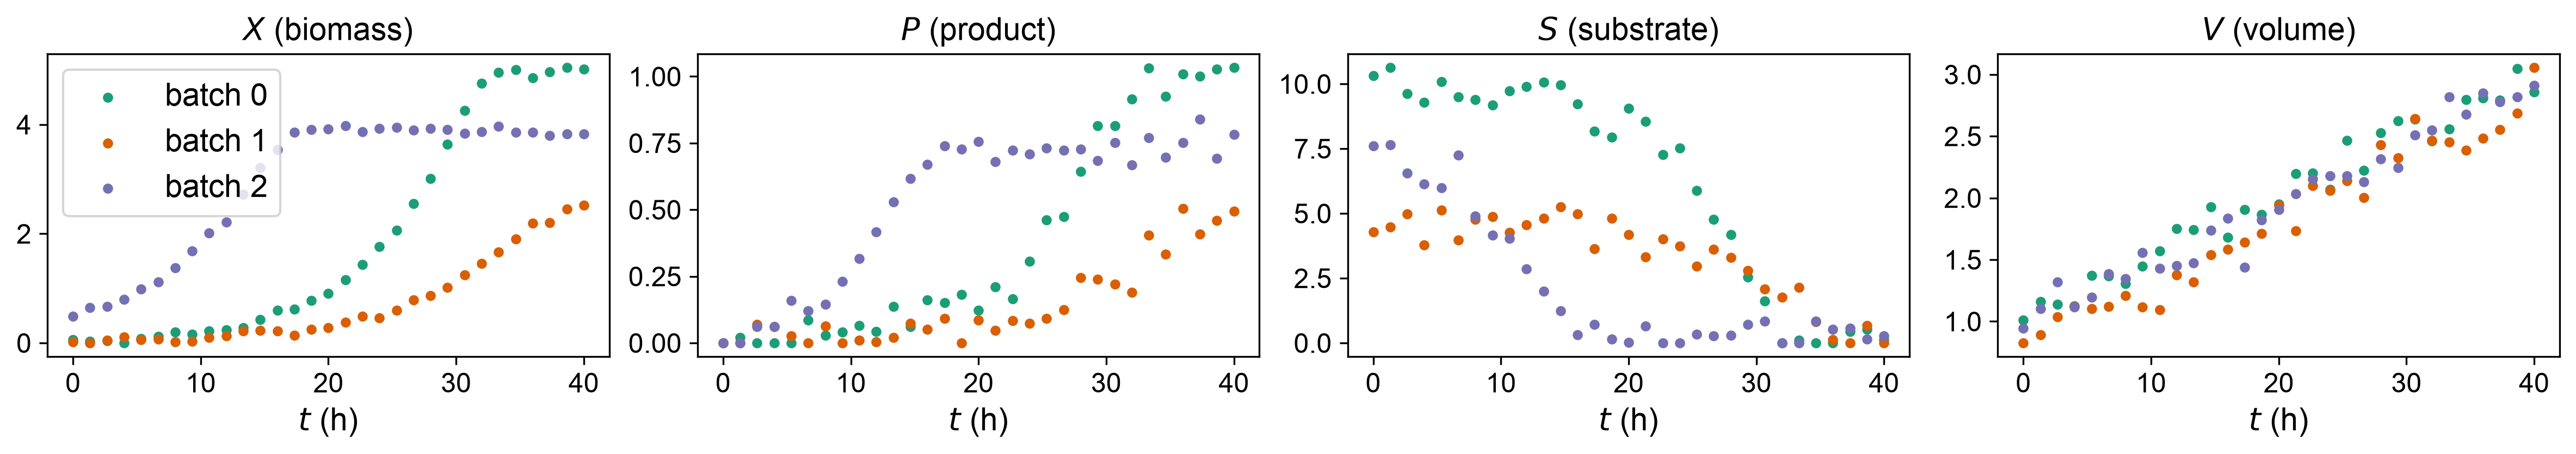

In [5]:
fig, axes = plt.subplots(1, 4, figsize=(16, 3))
for j, name in enumerate(STATE_NAMES):
    for b_ in range(len(obs_times)):
        axes[j].scatter(
            obs_times[b_],
            obs_values[b_][:, j],
            s=12,
            label=f"batch {b_}",
        )
    axes[j].set_title(name)
    axes[j].set_xlabel("$t$ (h)")
axes[0].legend()
plt.tight_layout()
plt.show()

## 2. A neural ODE, trained sequentially

The network for $\mu$, in [Equinox](https://docs.kidger.site/equinox/):

In [6]:
mu_scale = 0.3                                 # 1/h: sets the size of mu
x_typical = jnp.array([5.0, 1.0, 10.0, 3.0])   # typical X, P, S, V

class GrowthRate(eqx.Module):
    mlp: eqx.nn.MLP

    def __call__(self, x):
        out = self.mlp(x / x_typical)[0]       # any real number
        return mu_scale * jax.nn.softplus(out) # mu >= 0, of order mu_scale

The balances, as [Diffrax](https://docs.kidger.site/diffrax/) wants them:

In [7]:
def balances(t, x, args):
    mu_net, Sf = args
    X, P, S, V = x
    mu = mu_net(x)                               # the learned term
    dX = mu * X - F / V * X
    dP = Ypx * mu * X - F / V * P
    dS = F / V * (Sf - S) - mu * X / Yxs
    dV = F
    return jnp.array([dX, dP, dS, dV])

The solve: every operation is JAX, so `jax.grad` goes back through the solver.

In [8]:
def simulate(mu_net, x0, ts):
    sol = diffrax.diffeqsolve(
        diffrax.ODETerm(balances),
        diffrax.Tsit5(),
        t0=0.0,
        t1=ts[-1],
        dt0=0.1,
        y0=x0,
        args=(mu_net, x0[2]),
        saveat=diffrax.SaveAt(ts=ts),
        stepsize_controller=diffrax.PIDController(
            rtol=1e-6,
            atol=1e-8,
        ),
    )
    return sol.ys

The measurements as JAX arrays:

In [9]:
x0s = jnp.array(BATCH_ICS)
ts = jnp.array(t_obs)
ys = jnp.array(obs_values)
y_scale = ys.reshape(-1, 4).std(axis=0)
steps = 10_000

Training: every step simulates the three batches, then updates the weights. About 35 s.

In [10]:
def loss(mu_net):
    pred = jax.vmap(simulate, in_axes=(None, 0, None))(mu_net, x0s, ts)
    return jnp.mean(((pred - ys) / y_scale) ** 2)

mu_net = GrowthRate(eqx.nn.MLP(
    in_size=4,
    out_size=1,
    width_size=16,
    depth=2,
    activation=jnp.tanh,
    key=jax.random.PRNGKey(0),
))
opt = optax.adam(optax.cosine_decay_schedule(1e-2, steps, alpha=0.05))
state = opt.init(eqx.filter(mu_net, eqx.is_array))

@eqx.filter_jit
def step(mu_net, state):
    value, grads = eqx.filter_value_and_grad(loss)(mu_net)
    updates, state = opt.update(grads, state, mu_net)
    return eqx.apply_updates(mu_net, updates), state, value

for _ in range(10_000):
    mu_net, state, value = step(mu_net, state)

In [11]:
print(f"final loss {float(value):.4f}")

final loss 0.0184


## 3. A neural DAE, trained simultaneously

The problem, as in the SiNDAE example
[Importing Measured Data, Fed-Batch Bioreactor](https://alves-research-group.github.io/SiNDAE/fedbatch-example/),
with $F P / V$ in the product balance. The states are non-negative: here is $S \ge 0$.

In [12]:
class FedBatchBioreactorProblem(ProblemDefinition):
    def __init__(
        self,
        params,
        ics,
        input_dim,
        z_dim,
        t_span,
        nfe,
        ncp,
        obs_times=None,
        obs_values=None,
        obs_dim=None,
    ):
        super().__init__(ics, input_dim, z_dim, t_span, nfe, ncp,
                         obs_times, obs_values, obs_dim)
        self.params = params

    def build_trajectory(self, block, traj_idx):
        p = self.params
        t0 = self.t_span[0]
        x0 = self.ics[traj_idx]
        Sf = float(x0[2])                # feed concentration = initial substrate
        Feed, Ypx, Yxs = p["Feed"], p["Ypx"], p["Yxs"]

        block.t = dae.ContinuousSet(bounds=self.t_span)
        block.x = pyo.Var(
            block.t,
            range(self.input_dim),
            domain=pyo.NonNegativeReals,
            initialize=1.0,
        )
        block.z = pyo.Var(block.t, range(self.z_dim), initialize=0.1)
        block.dxdt = dae.DerivativeVar(block.x, wrt=block.t)

        @block.Constraint(block.t, range(self.input_dim))
        def diffeq(b, t, s):
            mu = b.z[t, 0]               # growth rate, learned by the network
            X, P, S, V = b.x[t, 0], b.x[t, 1], b.x[t, 2], b.x[t, 3]
            if s == 0:
                return b.dxdt[t, 0] == mu * X - Feed * (X / V)
            elif s == 1:
                return b.dxdt[t, 1] == Ypx * mu * X - Feed * (P / V)
            elif s == 2:
                return b.dxdt[t, 2] == Feed * (Sf - S) / V - mu * (X / Yxs)
            else:
                return b.dxdt[t, 3] == Feed

        for j in range(self.input_dim):
            block.x[t0, j].fix(float(x0[j]))

    def get_input_vars(self, block, t):
        return [block.x[t, j] for j in range(self.input_dim)]

    def get_output_vars(self, block, t):
        return [block.z[t, 0]]

The sizes, and the training grid: 40 finite elements of 3 collocation points.

In [13]:
INPUT_DIM = 4      # network inputs: X, P, S, V
Z_DIM = 1          # network output: mu
T_SPAN = (0.0, 40.0)
NFE_TRAIN = 40     # finite elements
NCP_TRAIN = 3      # collocation points per element
OBS_DIM = 4        # measured states

The network and the three training stages: smoother, pretraining, full NLP.

In [14]:
mlp = SimpleMLP(
    in_size=INPUT_DIM,
    out_size=Z_DIM,
    widths=[20, 20],
    activations=[jax.nn.softplus] * 2,
    key=jax.random.PRNGKey(SEED),
)
smoother_config = SmootherConfig(smooth_coef=10.0)
pretrain_config = PretrainConfig(
    epochs=200,
    batch_size=32,
    reg_coef=1e-3,
)
simul_config = SimultaneousConfig(
    use_gbm=True,
    reg_coef=1e-3,
)
solver_options = SolverConfig(
    tol=1e-6,
    max_iter=1000,
)

Attach the measurements and train. About 30 s.

In [15]:
problem = FedBatchBioreactorProblem(
    params=FB_PARAMS,
    ics=BATCH_ICS,
    input_dim=INPUT_DIM,
    z_dim=Z_DIM,
    t_span=T_SPAN,
    nfe=NFE_TRAIN,
    ncp=NCP_TRAIN,
    obs_dim=OBS_DIM,
    obs_times=obs_times,
    obs_values=obs_values,
)

In [16]:
model = HybridDAE(
    method="simultaneous",
    nlp_solver="pounce",
    net=mlp,
    smoother=smoother_config,
    pretrain=pretrain_config,
    train=simul_config,
    solver_options=solver_options,
    unfix_io=True,
)
model.fit(problem)

=== Building smoother for 3 trajectories (smooth_coef=10.0) ===


  Smoother: ok / optimal


=== Building simultaneous GBM model for 3 trajectories ===


=== Solving simultaneous GBM model (pounce, L-BFGS) ===


  pounce: ok / optimal


=== Simultaneous solve complete ===


solver status: optimal


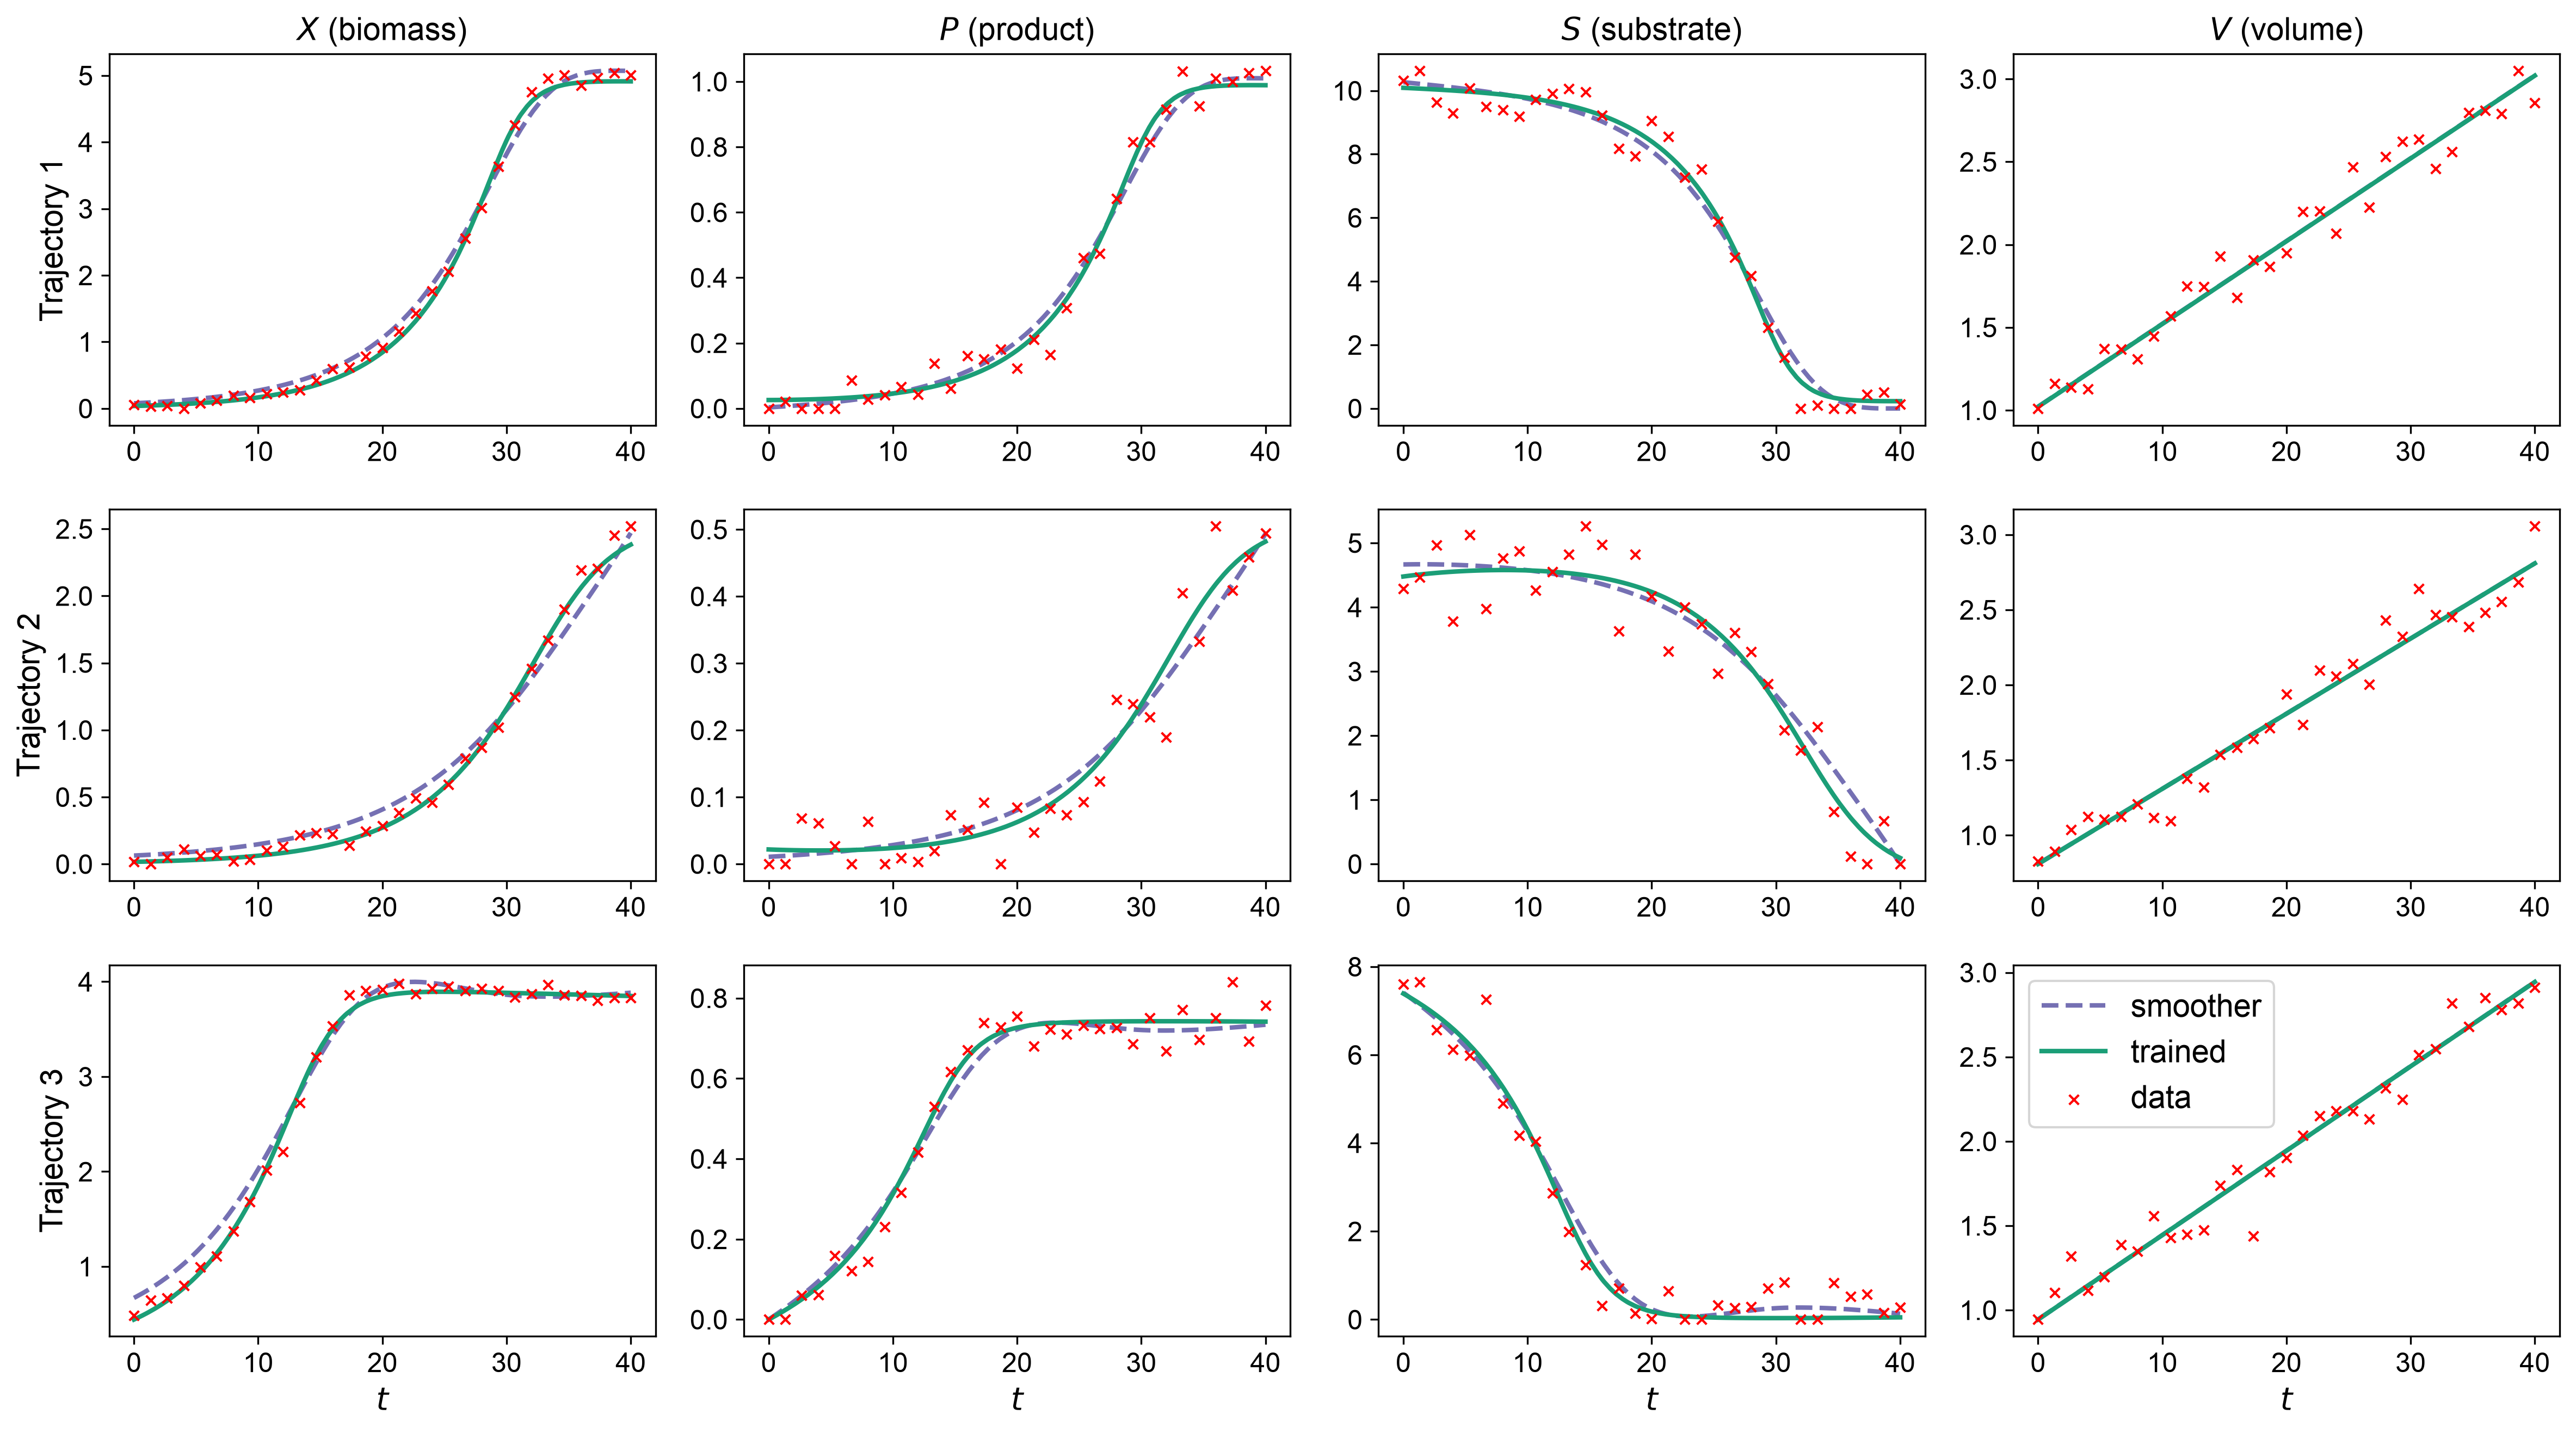

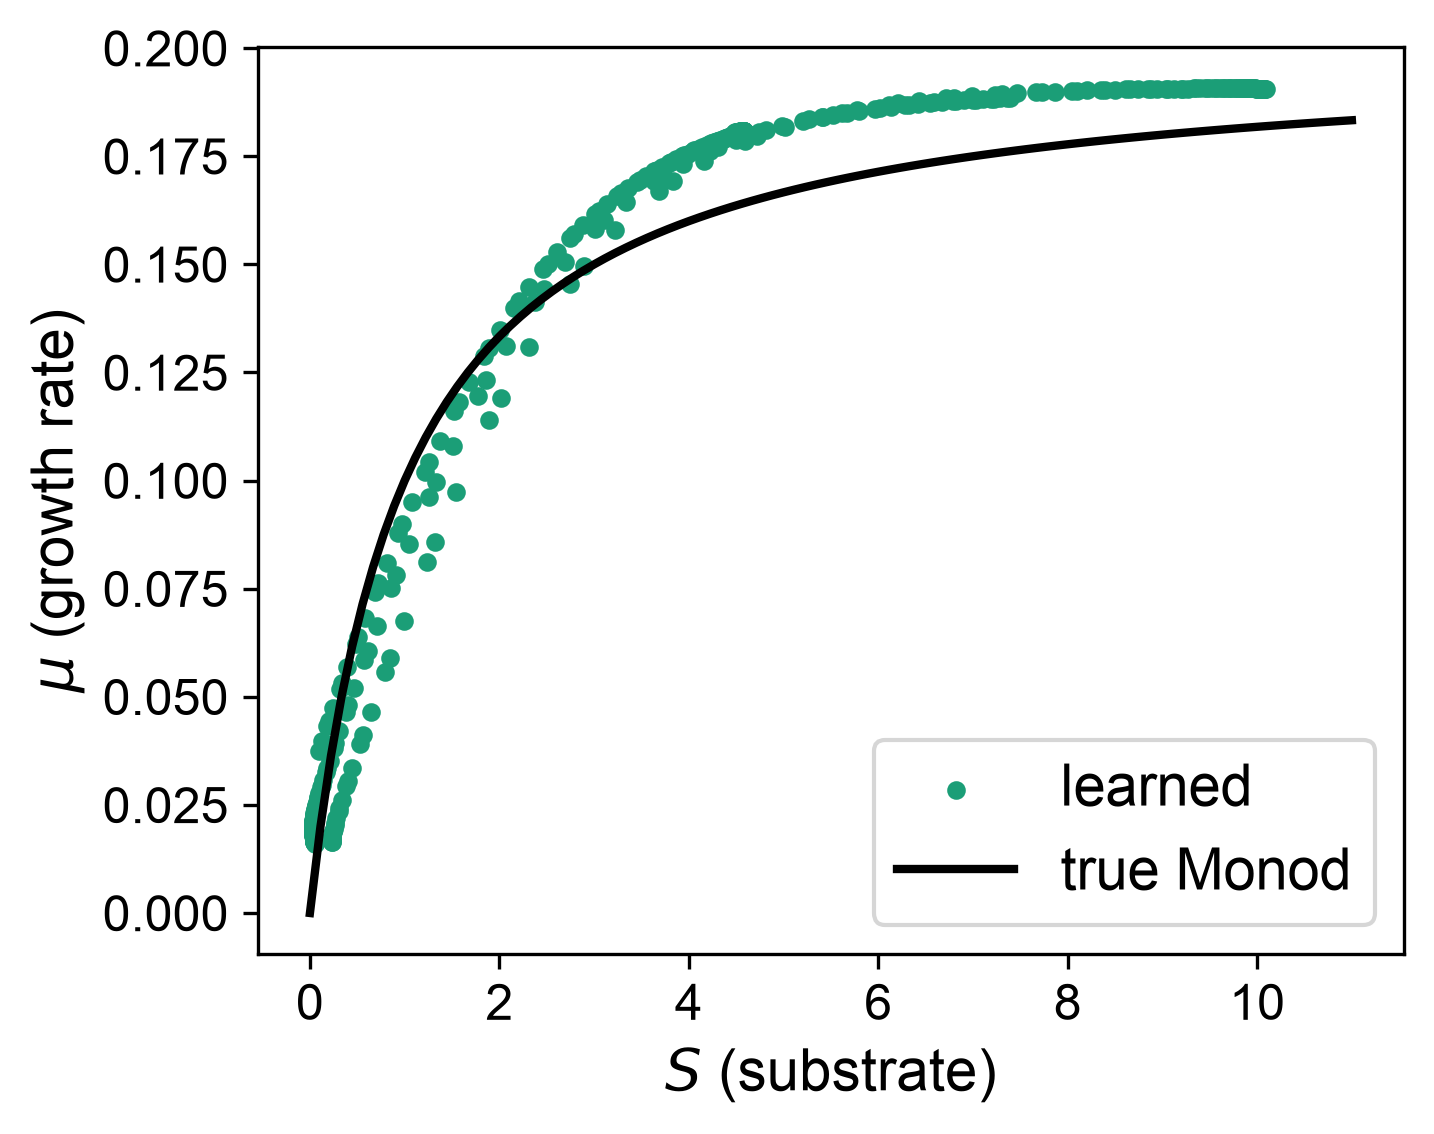

In [17]:
print(f"solver status: {model.termination}")
smoother_data = model.smoother_data
trained_data = model.trained_data

datasets = [
    (smoother_data, "smoother", {"color": "C2", "ls": "--"}),
    (trained_data, "trained", {"color": "C0", "ls": "-"}),
]
fig_x, _ = plot_instance_data(
    datasets=datasets,
    nn_input_names=STATE_NAMES,
    nn_output_names=OUTPUT_NAME,
    obs_times=problem.obs_times,
    obs_values=problem.obs_values,
    obs_names=STATE_NAMES,
    groups=["inputs"],
    legend_placement="last",
)
plt.show()

fig_mu, ax = plt.subplots(figsize=(5, 4))
for b_ in range(problem.num_trajectories):
    ax.scatter(
        trained_data[b_].nn_input[:, 2],
        trained_data[b_].nn_output[:, 0],
        s=12,
        color="C0",
        label="learned" if b_ == 0 else None,
    )
S_grid = np.linspace(0, 11, 100)
ax.plot(
    S_grid,
    FB_PARAMS["mu_max"] * S_grid / (FB_PARAMS["Ks"] + S_grid),
    "k-",
    label="true Monod",
)
ax.set_xlabel("$S$ (substrate)")
ax.set_ylabel(r"$\mu$ (growth rate)")
ax.legend()
plt.tight_layout()
plt.show()

## 4. A new batch, predicted by both

0.2 g/L of cells, 7 g/L of substrate and 0.9 L, run for 60 h: 20 h past the training batches.

In [18]:
new_problem = FedBatchBioreactorProblem(
    params=FB_PARAMS,
    ics=np.array([[0.20, 0.0, 7.0, 0.90]]),
    input_dim=INPUT_DIM,
    z_dim=Z_DIM,
    t_span=(0.0, 60.0),
    nfe=45,
    ncp=3,
    obs_dim=OBS_DIM,
)
prediction = model.predict(
    new_problem,
    slack_coef=1e-5,
)

=== Building inference model for 1 trajectories (slack_coef=1e-05) ===


=== Solving inference model ===


  Inference: ok / optimal


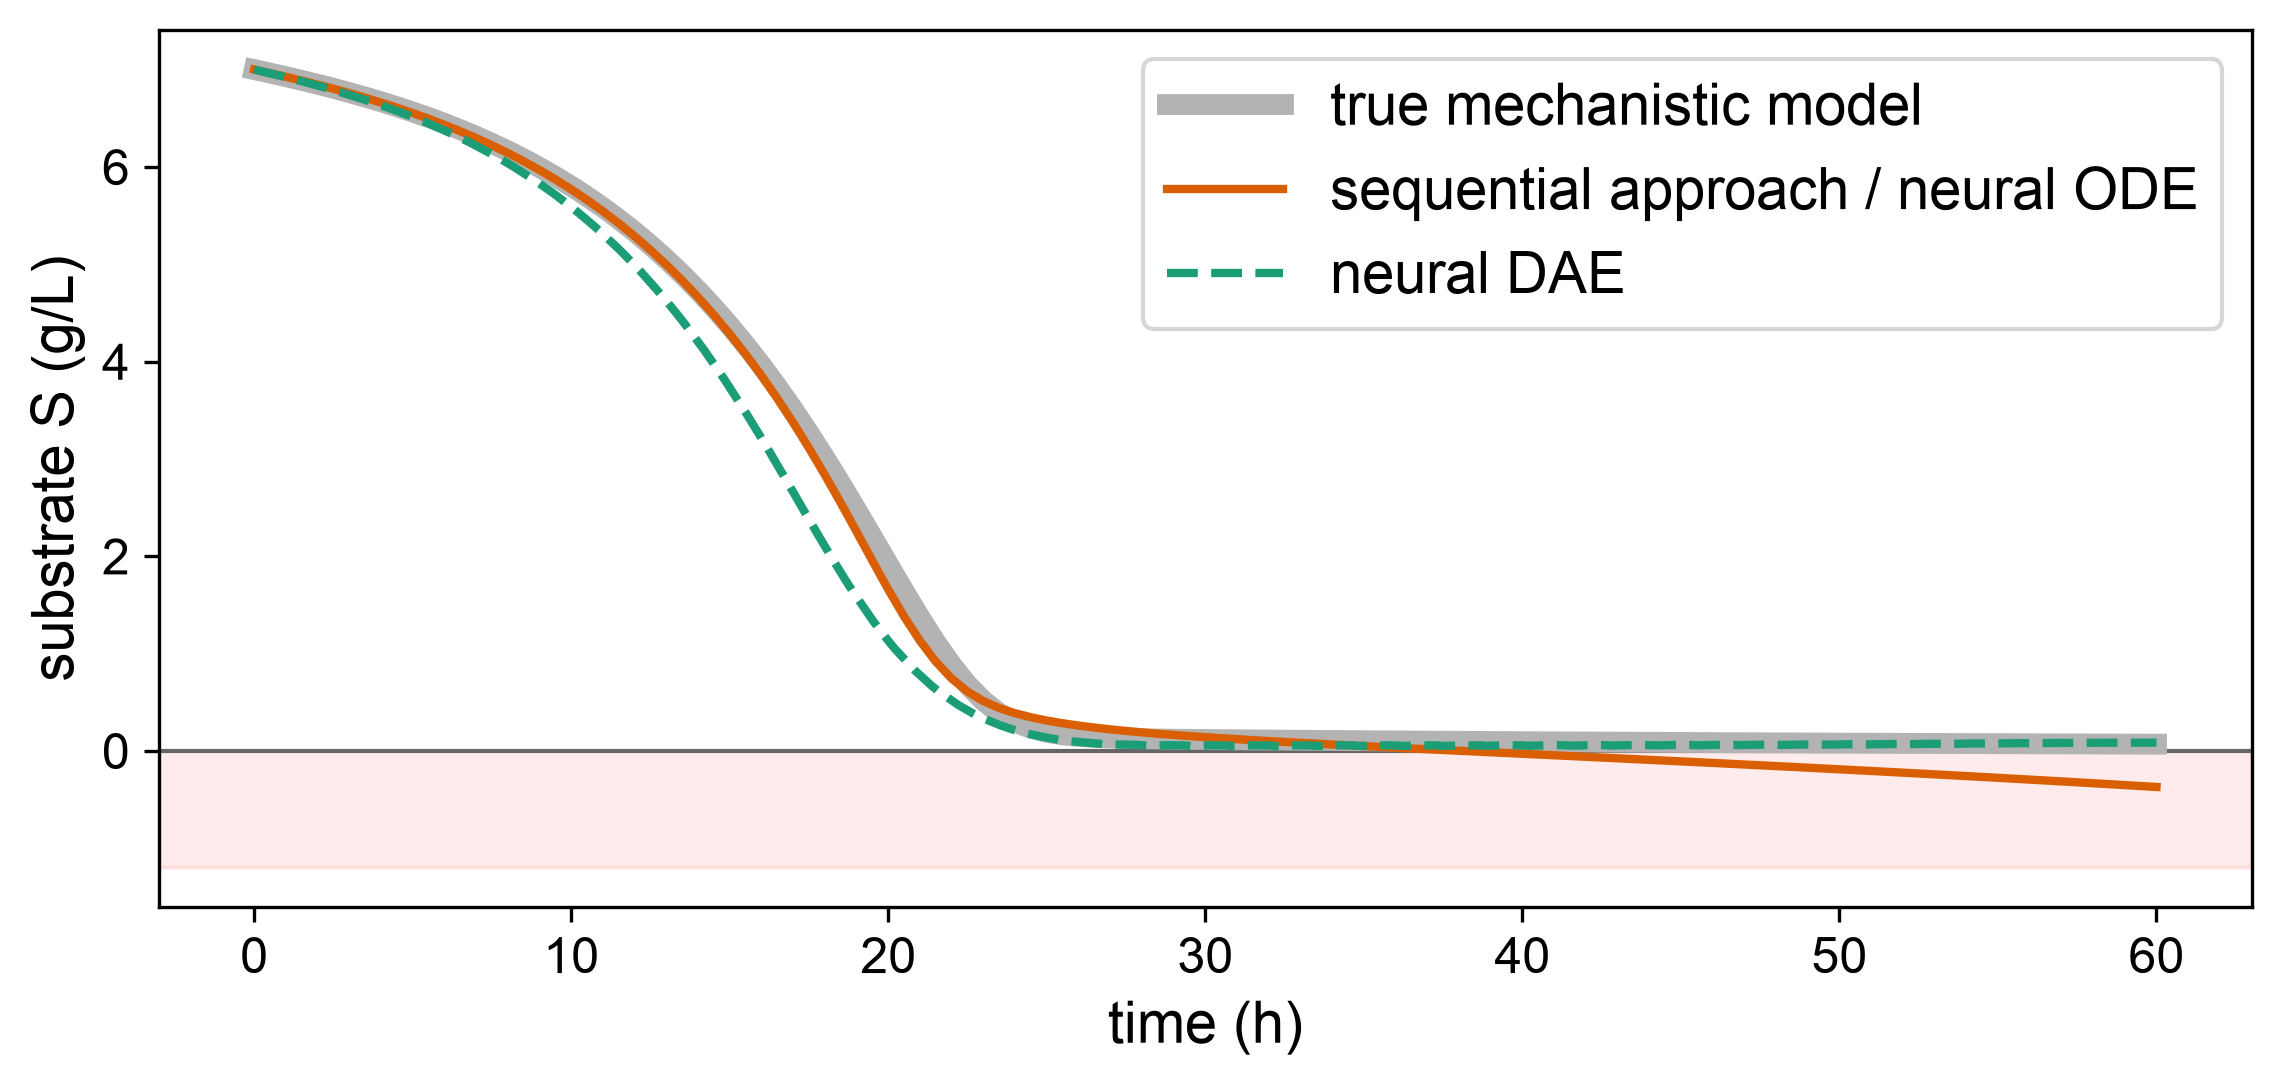

                            true model  neural ODE  neural DAE
lowest S (g/L)                    0.07       -0.37        0.05
hours with S < 0                     0          22           0
error in S, RMSE (g/L)                        0.19        0.30


In [19]:
ic_A = np.array([0.20, 0.0, 7.0, 0.90])
tt = np.linspace(0, 60, 121)
truth = solve_ivp(
    true_rhs,
    (0, 60),
    ic_A,
    t_eval=tt,
    args=(ic_A[2],),
    rtol=1e-10,
    atol=1e-12,
)
node = np.asarray(simulate(mu_net, jnp.array(ic_A), jnp.array(tt)))
pred_A = prediction[0]
t_dae = np.asarray(pred_A.sampling_times)
S_dae = pred_A.nn_input[:, 2]

fig, ax = plt.subplots(figsize=(9, 3.8))
ax.axhspan(
    -1.2,
    0,
    color="red",
    alpha=0.08,
)
ax.axhline(
    0,
    color="0.4",
    lw=1,
)
ax.plot(
    tt,
    truth.y[2],
    color="0.7",
    lw=5,
    label="true mechanistic model",
)
ax.plot(
    tt,
    node[:, 2],
    "C1",
    lw=2,
    label="sequential approach / neural ODE",
)
ax.plot(
    t_dae,
    S_dae,
    "C0--",
    lw=2,
    label="neural DAE",
)
ax.set_xlabel("time (h)")
ax.set_ylabel("substrate S (g/L)")
ax.legend()
plt.show()


def rmse(a, b):
    return np.sqrt(np.mean((a - b) ** 2))


S_node = node[:, 2]
S_dae_tt = np.interp(tt, t_dae, S_dae)
print(f"{'':26s}{'true model':>12s}{'neural ODE':>12s}{'neural DAE':>12s}")
print(f"{'lowest S (g/L)':26s}{truth.y[2].min():12.2f}{S_node.min():12.2f}{S_dae.min():12.2f}")
print(f"{'hours with S < 0':26s}{0:12d}{np.mean(S_node < 0) * 60:12.0f}{0:12d}")
print(f"{'error in S, RMSE (g/L)':26s}{'':12s}{rmse(S_node, truth.y[2]):12.2f}"
      f"{rmse(S_dae_tt, truth.y[2]):12.2f}")

The neural ODE drives the substrate below zero; the neural DAE keeps it at or above zero. A
feasible prediction is not automatically an accurate one: compare the errors too.